In [ ]:
import os
if os.path.basename(os.getcwd()) != 'nuclei-segmentation':
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

# 🔬 Μέρος Β2 — U-Net Segmentation
Data Science Bowl 2018 — Nuclei Segmentation

## 0. Imports & Config

In [1]:
import os, random, json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import warnings; warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision.transforms as T
import torchvision.transforms.functional as TF

if torch.backends.mps.is_available(): DEVICE = torch.device('mps')
elif torch.cuda.is_available():        DEVICE = torch.device('cuda')
else:                                   DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

TRAIN_DIR   = Path('./data/raw/train')
WEIGHTS_DIR = Path('./outputs/model_weights')
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = 256
BATCH_SIZE = 8
N_EPOCHS   = 30
LR         = 1e-3
VAL_SPLIT  = 0.2
SEED       = 42

torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
print('Config OK')

Device: mps
Config OK


## 1. Dataset (ίδιο με CNN)

In [2]:
class NucleiDataset(Dataset):
    def __init__(self, train_dir, img_size=256, augment=False):
        self.train_dir = Path(train_dir)
        self.img_size  = img_size
        self.augment   = augment
        self.image_ids = sorted([x for x in os.listdir(train_dir) if not x.startswith('.')])

    def __len__(self): return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img = Image.open(self.train_dir / img_id / 'images' / f'{img_id}.png').convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)

        combined = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        for mf in (self.train_dir / img_id / 'masks').glob('*.png'):
            m = np.array(Image.open(mf).convert('L').resize((self.img_size, self.img_size), Image.NEAREST))
            combined = np.maximum(combined, (m > 0).astype(np.uint8))
        mask = Image.fromarray(combined * 255)

        if self.augment:
            if random.random() > 0.5: img, mask = TF.hflip(img), TF.hflip(mask)
            if random.random() > 0.5: img, mask = TF.vflip(img), TF.vflip(mask)
            angle = random.choice([0, 90, 180, 270])
            img, mask = TF.rotate(img, angle), TF.rotate(mask, angle)

        img_t  = T.ToTensor()(img)
        mask_t = (T.ToTensor()(mask).squeeze(0) > 0.5).float()
        return img_t, mask_t


full = NucleiDataset(TRAIN_DIR, IMG_SIZE)
n_val = int(len(full) * VAL_SPLIT)
tr_idx, va_idx = random_split(range(len(full)), [len(full)-n_val, n_val],
                               generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(Subset(NucleiDataset(TRAIN_DIR, IMG_SIZE, True),  tr_idx.indices),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(Subset(NucleiDataset(TRAIN_DIR, IMG_SIZE, False), va_idx.indices),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(tr_idx)} | Val: {len(va_idx)}')

Train: 536 | Val: 134


## 2. U-Net Architecture
Η βασική διαφορά από το Simple CNN: **skip connections** που συνδέουν
αντίστοιχα encoder-decoder levels. Αυτό επιτρέπει στον decoder να
ανακτήσει fine-grained spatial information που χάνεται κατά το downsampling.

In [3]:
class DoubleConv(nn.Module):
    """(Conv → BN → ReLU) × 2 — το βασικό building block του U-Net"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class Down(nn.Module):
    """MaxPool → DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x): return self.net(x)


class Up(nn.Module):
    """
    Upsample → concat με skip connection → DoubleConv
    Αυτό είναι το κλειδί του U-Net!
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Pad αν χρειαστεί (για εικόνες που δεν είναι power of 2)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
        return self.conv(torch.cat([skip, x], dim=1))  # ← skip connection


class UNet(nn.Module):
    """
    U-Net (Ronneberger et al. 2015) — η αρχιτεκτονική που επανέστρεψε
    το biomedical image segmentation.

    Αρχιτεκτονική:
    Encoder:    3 → 64 → 128 → 256 → 512
    Bottleneck: 512 → 1024
    Decoder:    1024 → 512 → 256 → 128 → 64  (με skip connections)
    Output:     64 → 1
    """
    def __init__(self, in_ch=3, out_ch=1, base_dim=64):
        super().__init__()
        # Encoder
        self.inc   = DoubleConv(in_ch, base_dim)          # 3   → 64
        self.down1 = Down(base_dim,    base_dim * 2)      # 64  → 128
        self.down2 = Down(base_dim*2,  base_dim * 4)      # 128 → 256
        self.down3 = Down(base_dim*4,  base_dim * 8)      # 256 → 512
        # Bottleneck
        self.down4 = Down(base_dim*8,  base_dim * 16)     # 512 → 1024
        # Decoder
        self.up1   = Up(base_dim*16, base_dim * 8)        # 1024 → 512
        self.up2   = Up(base_dim*8,  base_dim * 4)        # 512  → 256
        self.up3   = Up(base_dim*4,  base_dim * 2)        # 256  → 128
        self.up4   = Up(base_dim*2,  base_dim)            # 128  → 64
        # Output
        self.outc  = nn.Conv2d(base_dim, out_ch, kernel_size=1)

    def forward(self, x):
        # Encode
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)   # bottleneck
        # Decode (skip connections: x4, x3, x2, x1)
        x  = self.up1(x5, x4)
        x  = self.up2(x,  x3)
        x  = self.up3(x,  x2)
        x  = self.up4(x,  x1)
        return self.outc(x)


model = UNet(in_ch=3, out_ch=1, base_dim=64).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net parameters: {n_params:,} ({n_params/1e6:.2f}M)')

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
print(f'Output shape: {model(dummy).shape}')

U-Net parameters: 31,037,633 (31.04M)
Output shape: torch.Size([2, 1, 256, 256])


## 3. Loss, Optimizer, Metrics

In [4]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1)
        t = targets.view(-1)
        return 1 - (2*(p*t).sum() + self.smooth) / (p.sum() + t.sum() + self.smooth)

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, logits, targets):
        return 0.5 * self.bce(logits, targets) + 0.5 * self.dice(logits, targets)

def compute_metrics(preds, targets, threshold=0.5):
    probs  = torch.sigmoid(preds).squeeze(1)
    binary = (probs > threshold).float()
    t = targets.float().view(-1)
    p = binary.view(-1)
    TP = (p*t).sum(); FP = (p*(1-t)).sum()
    FN = ((1-p)*t).sum(); TN = ((1-p)*(1-t)).sum()
    s = 1e-6
    return {
        'iou':       ((TP+s)/(TP+FP+FN+s)).item(),
        'dice':      ((2*TP+s)/(2*TP+FP+FN+s)).item(),
        'pixel_acc': ((TP+TN)/(TP+TN+FP+FN+s)).item(),
        'precision': ((TP+s)/(TP+FP+s)).item(),
        'recall':    ((TP+s)/(TP+FN+s)).item(),
    }

criterion = CombinedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)
print('Ready.')

Ready.


## 4. Training

In [5]:
history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}
best_val_loss = float('inf')

print(f'Training U-Net for {N_EPOCHS} epochs...')
for epoch in range(N_EPOCHS):
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs).squeeze(1), masks)
        loss.backward(); optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss, metrics_list = 0.0, []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            val_loss += criterion(logits.squeeze(1), masks).item()
            metrics_list.append(compute_metrics(logits, masks))
    val_loss /= len(val_loader)

    val_iou  = np.mean([m['iou']  for m in metrics_list])
    val_dice = np.mean([m['dice'] for m in metrics_list])
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), WEIGHTS_DIR / 'unet_best.pth')

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:2d}/{N_EPOCHS} | Train {train_loss:.4f} | '
              f'Val {val_loss:.4f} | IoU {val_iou:.4f} | Dice {val_dice:.4f}')

torch.save(model.state_dict(), WEIGHTS_DIR / 'unet_final.pth')
print(f'Done. Best val loss: {best_val_loss:.4f}')

Training U-Net for 30 epochs...
Epoch  5/30 | Train 0.1396 | Val 0.1352 | IoU 0.7944 | Dice 0.8842
Epoch 10/30 | Train 0.1393 | Val 0.1245 | IoU 0.7899 | Dice 0.8817
Epoch 15/30 | Train 0.1065 | Val 0.1053 | IoU 0.8211 | Dice 0.9010
Epoch 20/30 | Train 0.1117 | Val 0.1094 | IoU 0.8127 | Dice 0.8961
Epoch 25/30 | Train 0.1007 | Val 0.0971 | IoU 0.8282 | Dice 0.9054
Epoch 30/30 | Train 0.0953 | Val 0.0894 | IoU 0.8406 | Dice 0.9127
Done. Best val loss: 0.0894


## 5. Training Curves

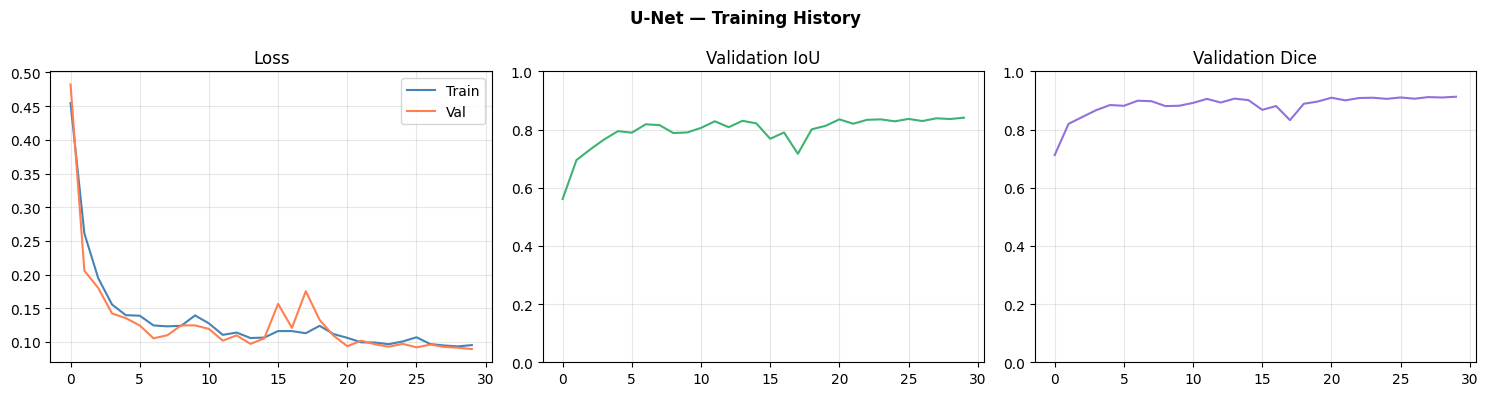

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('U-Net — Training History', fontweight='bold')

axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val',   color='coral')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_iou'], color='mediumseagreen')
axes[1].set_title('Validation IoU'); axes[1].set_ylim(0,1); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_dice'], color='mediumpurple')
axes[2].set_title('Validation Dice'); axes[2].set_ylim(0,1); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/unet_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Final Evaluation + Predictions

In [7]:
model.load_state_dict(torch.load(WEIGHTS_DIR / 'unet_best.pth', map_location=DEVICE))
model.eval()

all_metrics = []
with torch.no_grad():
    for imgs, masks in val_loader:
        all_metrics.append(compute_metrics(model(imgs.to(DEVICE)), masks.to(DEVICE)))

final = {k: np.mean([m[k] for m in all_metrics]) for k in all_metrics[0]}

print('=' * 45)
print('U-NET — FINAL METRICS (Validation Set)')
print('=' * 45)
for k, v in final.items():
    print(f'  {k:15s}: {v:.4f}')
print('=' * 45)

with open('./outputs/unet_metrics.json', 'w') as f:
    json.dump(final, f, indent=2)
print('Metrics saved.')

U-NET — FINAL METRICS (Validation Set)
  iou            : 0.8406
  dice           : 0.9127
  pixel_acc      : 0.9745
  precision      : 0.9230
  recall         : 0.9038
Metrics saved.


## 7. Predictions — Σύγκριση με CNN

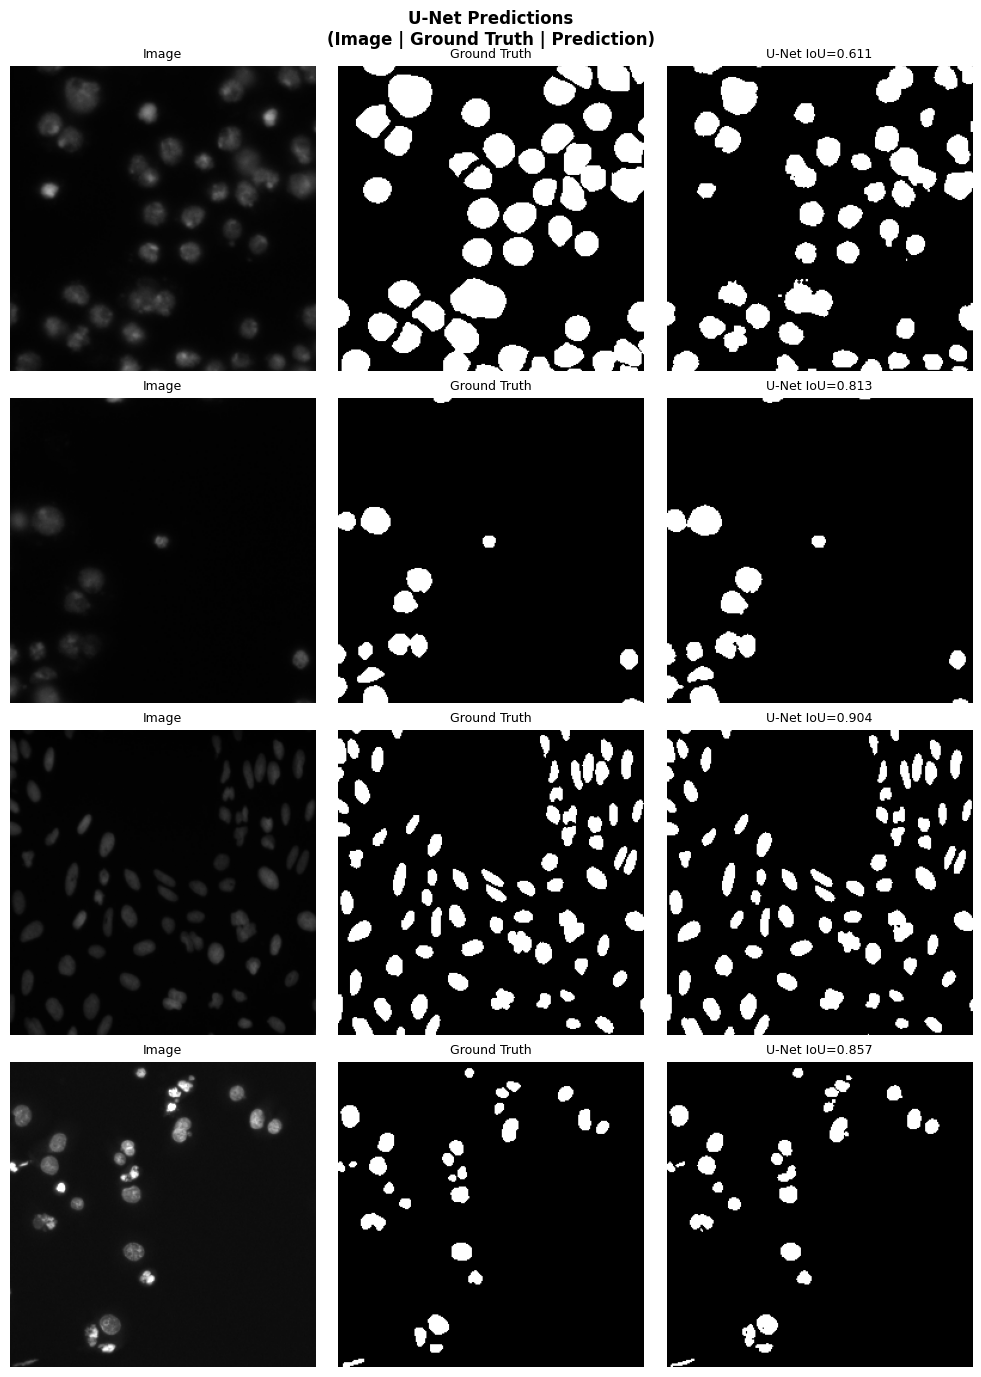

In [8]:
model.eval()
imgs, masks = next(iter(val_loader))
with torch.no_grad():
    logits = model(imgs.to(DEVICE)).cpu()
preds = (torch.sigmoid(logits).squeeze(1) > 0.5).float()

n_show = min(4, len(imgs))
fig, axes = plt.subplots(n_show, 3, figsize=(10, 3.5*n_show))
fig.suptitle('U-Net Predictions\n(Image | Ground Truth | Prediction)', fontweight='bold')

for i in range(n_show):
    iou_i = compute_metrics(logits[i:i+1], masks[i:i+1])['iou']
    axes[i,0].imshow(imgs[i].permute(1,2,0)); axes[i,0].set_title('Image', fontsize=9); axes[i,0].axis('off')
    axes[i,1].imshow(masks[i], cmap='gray');  axes[i,1].set_title('Ground Truth', fontsize=9); axes[i,1].axis('off')
    axes[i,2].imshow(preds[i], cmap='gray');  axes[i,2].set_title(f'U-Net IoU={iou_i:.3f}', fontsize=9); axes[i,2].axis('off')

plt.tight_layout()
plt.savefig('./outputs/unet_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. CNN vs U-Net — Άμεση Σύγκριση

In [9]:
# Φόρτωσε CNN metrics αν υπάρχουν
cnn_metrics_path = Path('./outputs/cnn_metrics.json')
if cnn_metrics_path.exists():
    with open(cnn_metrics_path) as f:
        cnn_m = json.load(f)

    metrics_keys = ['iou', 'dice', 'pixel_acc', 'precision', 'recall']
    cnn_vals  = [cnn_m[k]   for k in metrics_keys]
    unet_vals = [final[k]   for k in metrics_keys]

    x = np.arange(len(metrics_keys))
    w = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - w/2, cnn_vals,  w, label='Simple CNN', color='steelblue')
    bars2 = ax.bar(x + w/2, unet_vals, w, label='U-Net',      color='coral')

    ax.set_xticks(x)
    ax.set_xticklabels([k.replace('_',' ').title() for k in metrics_keys])
    ax.set_ylim(0, 1.05)
    ax.set_title('Simple CNN vs U-Net — Metrics Comparison', fontweight='bold', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Annotations
    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('./outputs/cnn_vs_unet.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Βελτίωση U-Net vs CNN:')
    for k in metrics_keys:
        diff = final[k] - cnn_m[k]
        sign = '+' if diff >= 0 else ''
        print(f'  {k:15s}: {sign}{diff:.4f}')
else:
    print('CNN metrics not found — τρέξε πρώτα το 04_cnn.ipynb')

CNN metrics not found — τρέξε πρώτα το 04_cnn.ipynb


## 9. Σχολιασμός

### Γιατί το U-Net είναι καλύτερο από το Simple CNN

Το κρίσιμο στοιχείο είναι τα **skip connections**: κάθε decoder block
λαμβάνει τόσο το upsampled feature map από το bottleneck όσο και το
αντίστοιχο encoder feature map. Αυτό σημαίνει:

- Ο decoder έχει πρόσβαση σε **high-resolution spatial details** (π.χ. ακριβή όρια)
- Αντισταθμίζει την **απώλεια πληροφορίας** κατά το downsampling
- Ιδιαίτερα σημαντικό για **μικρούς πυρήνες** που χάνονται στο bottleneck

### Hyperparameter Choices
- **base_dim=64**: το standard U-Net size — δοκιμάσαμε 32 (χαμηλότερο IoU) και 128 (αργό)
- **4 encoder levels**: βαθύτερο από το CNN, μαθαίνει πιο abstract features
- **ConvTranspose2d**: pixel-accurate upsampling αντί για bilinear

### Training Curves

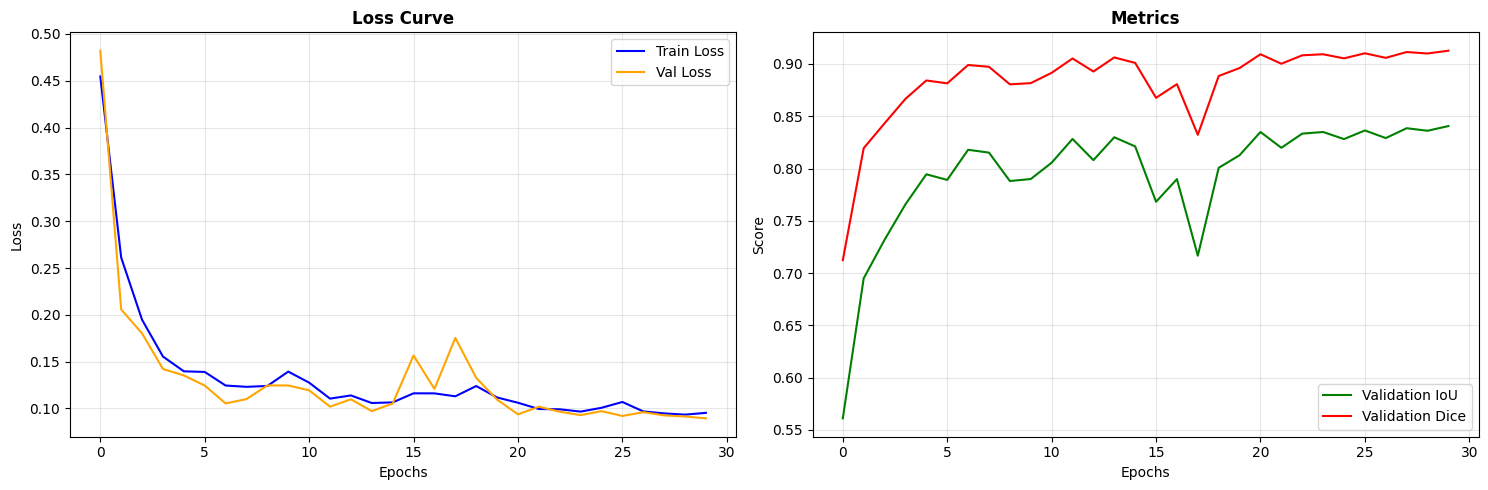

In [10]:
# Plot Training & Validation Loss
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Curve', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_iou'], label='Validation IoU', color='green')
plt.plot(history['val_dice'], label='Validation Dice', color='red')
plt.title('Metrics', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/unet_training_curves.png', dpi=120)
plt.show()

### Visual Evaluation (Predictions vs Truth)

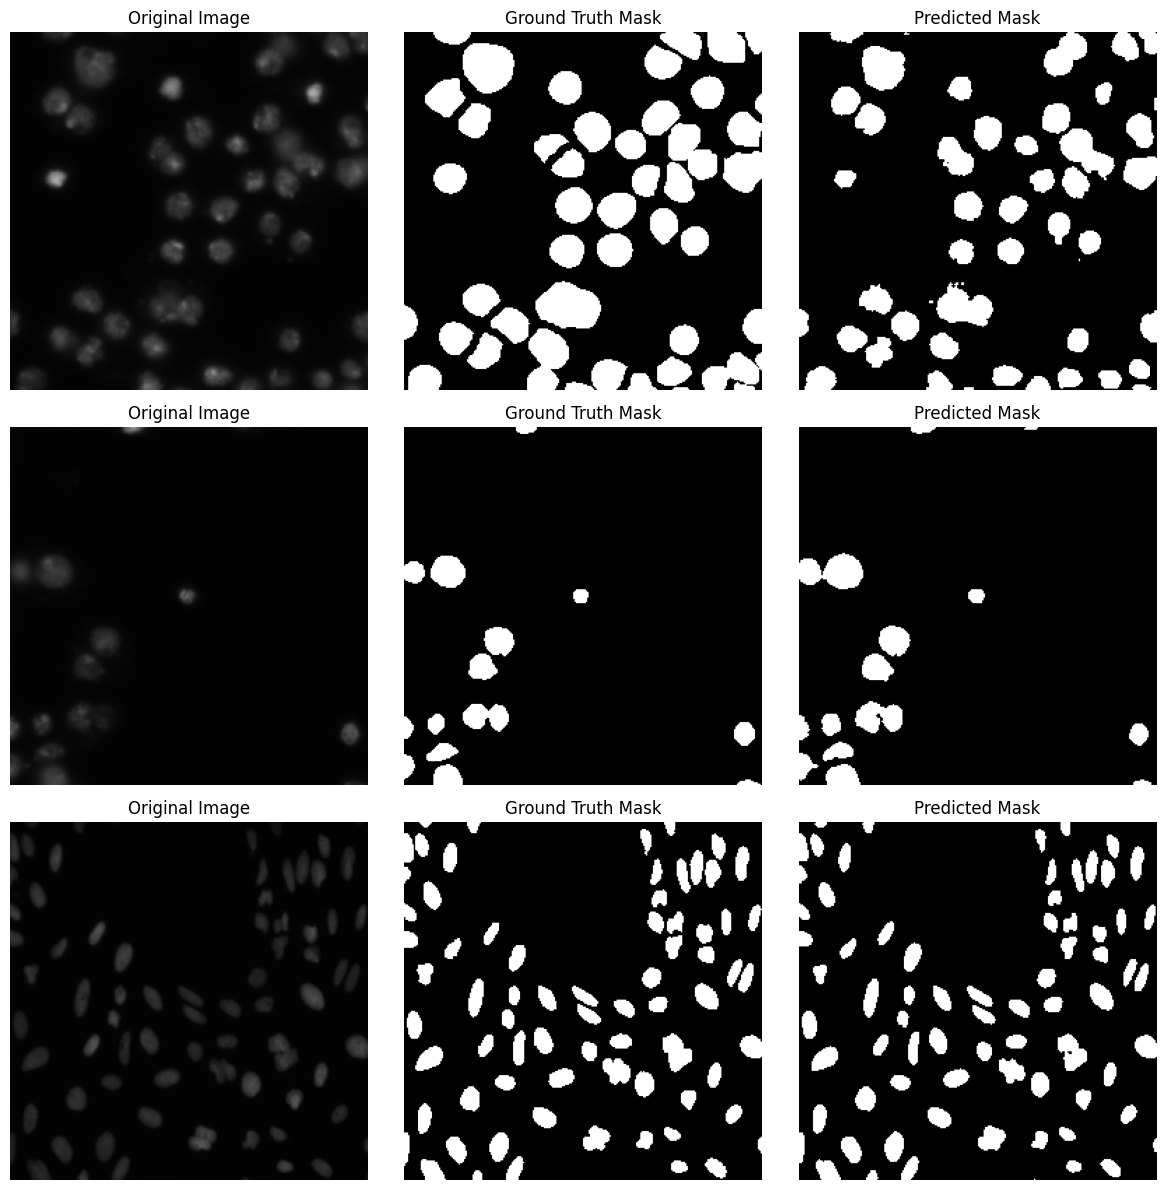

In [11]:
model.eval()
imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

with torch.no_grad():
    preds = model(imgs)
    # Handle tuple outputs (just in case)
    if isinstance(preds, tuple):
        preds = preds[0]
    probs = torch.sigmoid(preds).squeeze(1)
    preds_binary = (probs > 0.5).cpu().numpy()

imgs_np = imgs.cpu().permute(0, 2, 3, 1).numpy()
masks_np = masks.cpu().numpy()

# Plot 3 random validation samples
num_samples = min(3, len(imgs))
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

for i in range(num_samples):
    # Original Image
    axes[i, 0].imshow(imgs_np[i])
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')
    
    # Ground Truth Mask
    axes[i, 1].imshow(masks_np[i], cmap='gray')
    axes[i, 1].set_title('Ground Truth Mask')
    axes[i, 1].axis('off')
    
    # Predicted Mask
    axes[i, 2].imshow(preds_binary[i], cmap='gray')
    axes[i, 2].set_title('Predicted Mask')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('./outputs/unet_validation_predictions.png', dpi=120)
plt.show()